In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('ushape.csv')

In [5]:
df

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0
...,...,...,...
95,1.699453,0.587720,1.0
96,0.218623,-0.652521,1.0
97,0.952914,-0.419766,1.0
98,-1.318500,0.423112,0.0


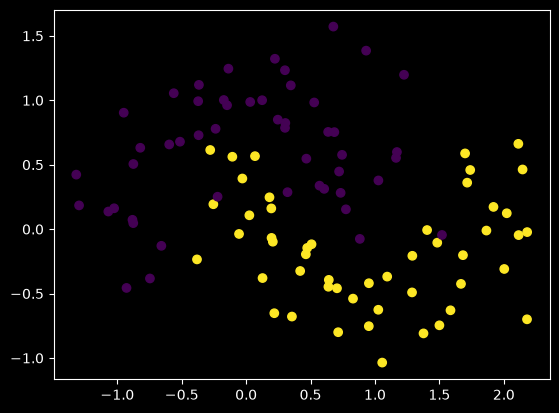

In [6]:
plt.scatter(x=df['X'],y=df['Y'],c=df['class'])

In [7]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [10]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


I0000 00:00:1790089686.614993    1458 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790089686.715408    1458 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790089688.080332    1458 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790089718.304859    1458 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [11]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/mnt/c/Users/vinay kumar/Desktop/Deep-Learning/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790089744.490867    1458 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
# Set parameters to 0
model.get_weights()

[array([[ 0.28657293,  0.09670663,  0.32527727, -0.6881641 ,  0.23606163,
          0.05536377, -0.20313632, -0.19437623, -0.26855144,  0.5311106 ],
        [-0.6155001 , -0.59605557, -0.43070588, -0.16797763, -0.03787518,
         -0.3709457 , -0.40280887, -0.3624555 ,  0.5217965 , -0.5079907 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.6115601 ],
        [ 0.46782523],
        [-0.33941683],
        [ 0.684365  ],
        [ 0.6218601 ],
        [ 0.31623167],
        [ 0.01112622],
        [-0.46859118],
        [ 0.63996774],
        [ 0.55125314]], dtype=float32),
 array([0.], dtype=float32)]

In [13]:
initial_weights = model.get_weights()

In [15]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [16]:
model.set_weights(initial_weights)

In [17]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [19]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.4750 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss:

In [ ]:
model.get_weights()  # See below all weights are same , when they are initialized with Zero

[array([[ 0.43326104,  0.43326104,  0.43326104,  0.43326104,  0.43326104,
          0.43326104,  0.43326104,  0.43326104,  0.43326104,  0.43326104],
        [-0.46786588, -0.46786588, -0.46786588, -0.46786588, -0.46786588,
         -0.46786588, -0.46786588, -0.46786588, -0.46786588, -0.46786588]],
       dtype=float32),
 array([-0.13078395, -0.13078395, -0.13078395, -0.13078395, -0.13078395,
        -0.13078395, -0.13078395, -0.13078395, -0.13078395, -0.13078395],
       dtype=float32),
 array([[0.05929966],
        [0.05929966],
        [0.05929966],
        [0.05929966],
        [0.05929966],
        [0.05929966],
        [0.05929966],
        [0.05929966],
        [0.05929966],
        [0.05929966]], dtype=float32),
 array([-0.06520168], dtype=float32)]

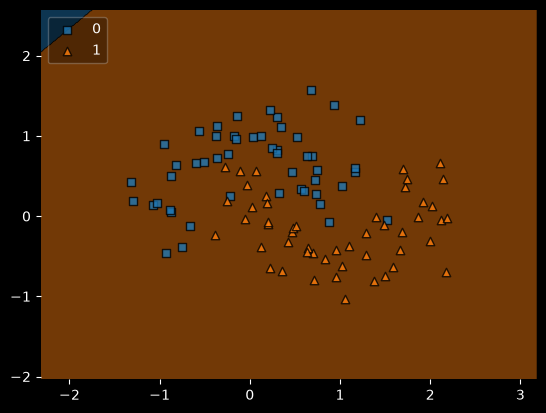

In [ ]:
from mlxtend.plotting import plot_decision_regions

class MyClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_pred = self.model.predict(X, verbose=0)
        return (y_pred > 0.5).astype(int).ravel()


clf = MyClassifier(model)

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.show()

# See below graph it is not at classifying the data